In [67]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [68]:
mnist = keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [69]:
print(x_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


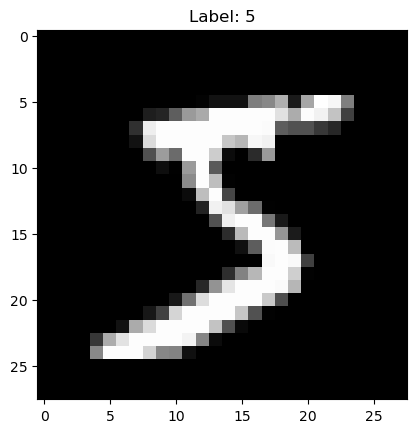

In [70]:
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.show()

In [71]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [72]:
print(x_train.min())
print(x_train.max())

0.0
1.0


In [73]:
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [74]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [75]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
history = model.fit(
    x_train,
    y_train,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9264 - loss: 0.2566
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9667 - loss: 0.1120
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9766 - loss: 0.0770
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9822 - loss: 0.0586
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9861 - loss: 0.0449


In [77]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9758 - loss: 0.0761
Test Accuracy: 0.9757999777793884


In [78]:
predictions = model.predict(x_test)

print(predictions[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[1.6979934e-08 1.8143083e-09 7.7215764e-06 3.2204363e-05 1.9310087e-12
 5.7081935e-09 1.9506786e-14 9.9995995e-01 3.3694452e-08 5.4869641e-08]


In [79]:
import numpy as np

print(np.argmax(predictions[0]))
print(y_test[0])

7
7


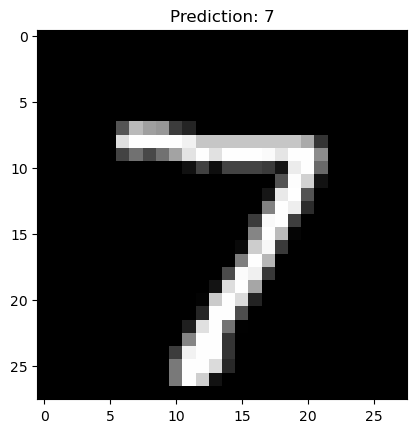

In [80]:
plt.imshow(x_test[0], cmap="gray")
plt.title(f"Prediction: {np.argmax(predictions[0])}")
plt.show()

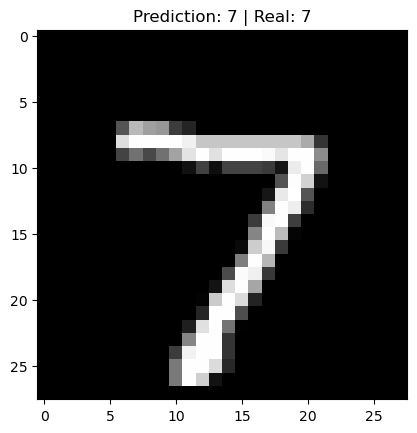

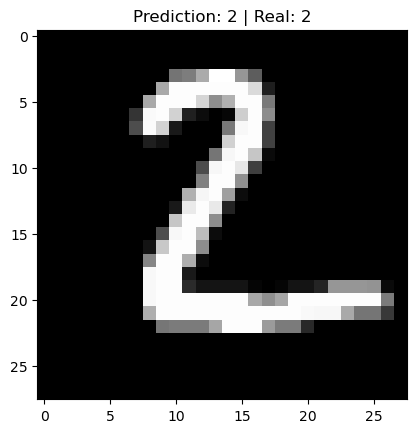

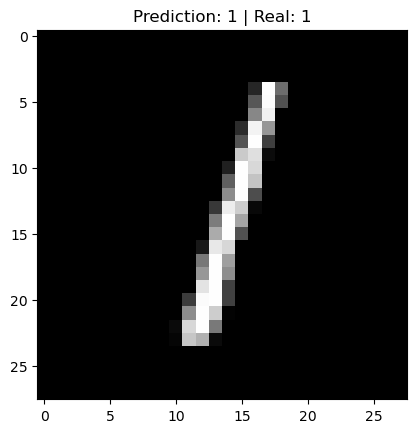

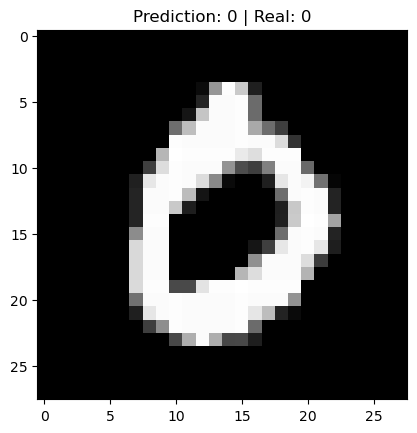

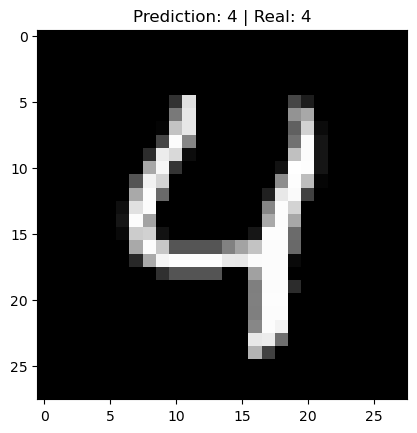

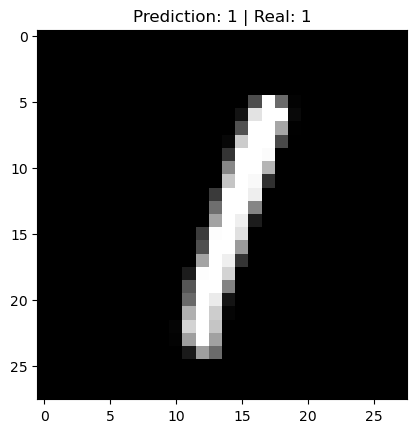

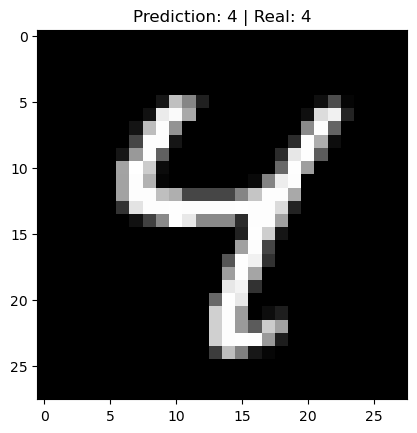

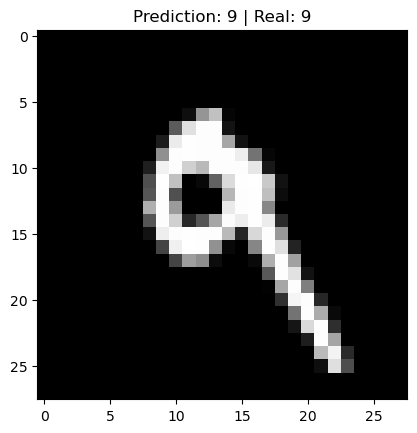

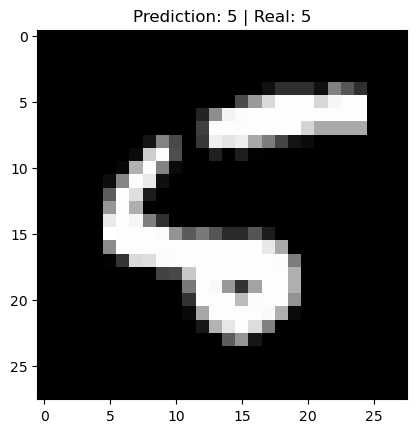

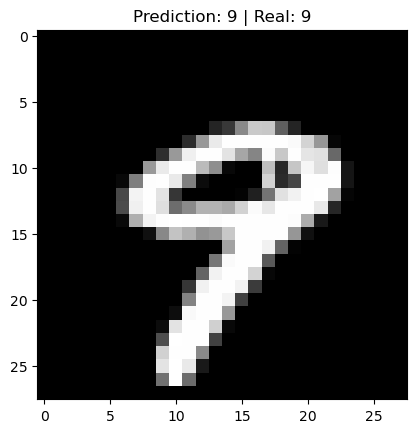

In [81]:
for i in range(10):
    plt.imshow(x_test[i], cmap="gray")
    plt.title(
        f"Prediction: {np.argmax(predictions[i])} | Real: {y_test[i]}"
    )
    plt.show()

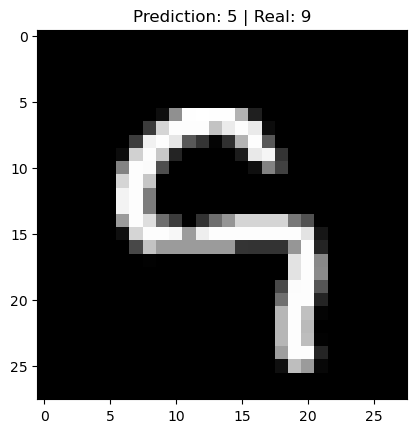

In [82]:
for i in range(len(x_test)):
    predicted = np.argmax(predictions[i])

    if predicted != y_test[i]:
        plt.imshow(x_test[i], cmap="gray")
        plt.title(
            f"Prediction: {predicted} | Real: {y_test[i]}"
        )
        plt.show()
        break

In [83]:
model.save("mnist_model.keras")

In [84]:
loaded_model = keras.models.load_model("mnist_model.keras")

In [85]:
loaded_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9758 - loss: 0.0761


[0.07610511779785156, 0.9757999777793884]

In [86]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [87]:
def prepare_image(path):
    img = Image.open(path)

    # تبدیل به سیاه و سفید
    img = img.convert("L")

    # تغییر اندازه
    img = img.resize((28, 28))

    # تبدیل به آرایه
    img_array = np.array(img)

    # معکوس کردن رنگ‌ها
    img_array = 255 - img_array

    # نرمال‌سازی
    img_array = img_array / 255.0

    return img_array

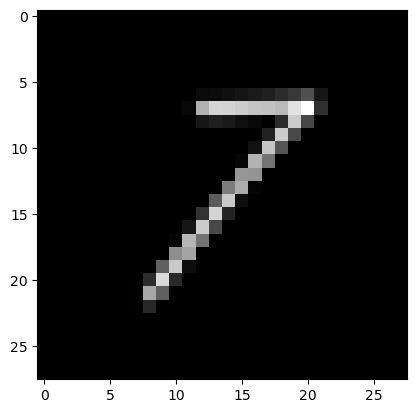

In [99]:
img2 = prepare_image("test7.jpg")

plt.imshow(img2, cmap="gray")
plt.show()

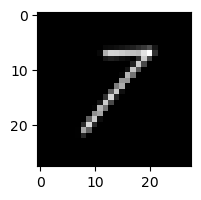

In [100]:
plt.figure(figsize=(2,2))
plt.imshow(img2, cmap="gray")
plt.show()

In [103]:
prediction7 = model.predict(img2.reshape(1,28,28))

print(np.argmax(prediction7))
print(prediction7)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
7
[[0.00096377 0.23947652 0.20393902 0.00954118 0.00038249 0.0062287
  0.00048643 0.3707422  0.15495676 0.01328292]]


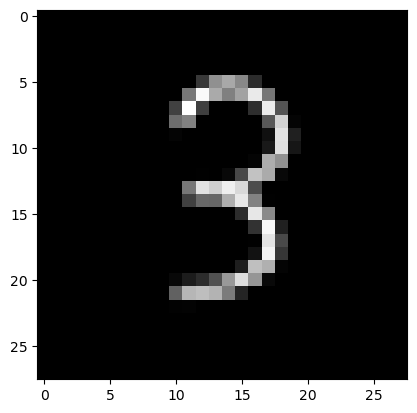

In [88]:
img = prepare_image("test3.jpg")

plt.imshow(img, cmap="gray")
plt.show()

In [89]:
prediction3 = model.predict(img.reshape(1, 28, 28))

print("Predicted:", np.argmax(prediction3))
print(prediction3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted: 3
[[1.10474566e-05 1.11669244e-04 4.08075238e-03 9.57176626e-01
  2.62985159e-05 8.89136456e-03 5.91847056e-05 6.52432069e-03
  8.63552187e-03 1.44831249e-02]]


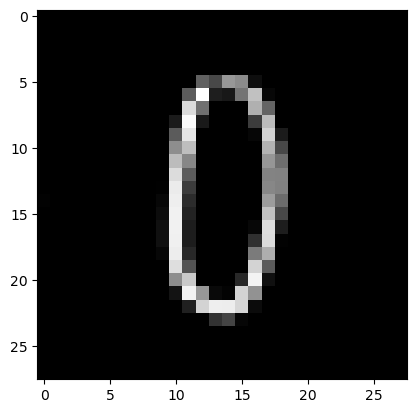

In [104]:
img3 = prepare_image("test0.jpg")

plt.imshow(img3, cmap="gray")
plt.show()

In [105]:
prediction0 = model.predict(img.reshape(1, 28, 28))

print("Predicted:", np.argmax(prediction0))
print(prediction0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted: 0
[[6.6319084e-01 1.4417390e-04 2.9258899e-02 9.0961996e-04 3.1652071e-02
  5.7199109e-02 1.8336290e-02 9.3601122e-02 2.9792402e-02 7.5915448e-02]]
